In [24]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder

pd.set_option('display.max_columns', None)

In [25]:
df = pd.read_csv('github_top_repos.csv')

print("Shape:", df.shape)
print("\nColumn names:\n", df.columns.tolist())
print("\nFirst 5 rows:")
df.head()

Shape: (1000, 26)

Column names:
 ['id', 'full_name', 'html_url', 'description', 'language', 'created_at', 'updated_at', 'pushed_at', 'stargazers_count', 'watchers_count', 'forks_count', 'open_issues_count', 'size', 'has_issues', 'has_projects', 'has_wiki', 'has_pages', 'has_downloads', 'archived', 'disabled', 'license_key', 'license_name', 'topics', 'default_branch', 'network_count', 'subscribers_count']

First 5 rows:


,id,full_name,html_url,description,language,created_at,updated_at,pushed_at,stargazers_count,watchers_count,forks_count,open_issues_count,size,has_issues,has_projects,has_wiki,has_pages,has_downloads,archived,disabled,license_key,license_name,topics,default_branch,network_count,subscribers_count
0,132750724,codecrafters-io/build-your-own-x,https://github.com/codecrafters-io/build-your-...,Master programming by recreating your favorite...,Markdown,2018-05-09T12:03:18Z,2026-05-18T08:36:09Z,2026-02-21T09:34:54Z,502118,502118,47613,484,1201,True,False,False,False,True,False,False,NaN,NaN,awesome-list;free;programming;tutorial-code;tu...,master,NaN,NaN
1,21737465,sindresorhus/awesome,https://github.com/sindresorhus/awesome,😎 Awesome lists about all kinds of interesting...,NaN,2014-07-11T13:42:37Z,2026-05-18T08:35:41Z,2026-05-05T14:47:44Z,467555,467555,35048,76,1561,True,False,False,True,True,False,False,cc0-1.0,Creative Commons Zero v1.0 Universal,awesome;awesome-list;lists;resources;unicorns,main,NaN,NaN
2,28457823,freeCodeCamp/freeCodeCamp,https://github.com/freeCodeCamp/freeCodeCamp,freeCodeCamp.org's open-source codebase and cu...,TypeScript,2014-12-24T17:49:19Z,2026-05-18T08:30:53Z,2026-05-18T08:09:38Z,445054,445054,44621,185,572380,True,True,False,False,True,False,False,bsd-3-clause,"BSD 3-Clause ""New"" or ""Revised"" License",careers;certification;community;curriculum;d3;...,main,NaN,NaN
3,54346799,public-apis/public-apis,https://github.com/public-apis/public-apis,A collective list of free APIs,Python,2016-03-20T23:49:42Z,2026-05-18T08:32:23Z,2026-05-15T15:50:51Z,435595,435595,47750,1342,5362,True,False,False,False,True,False,False,mit,MIT License,api;apis;dataset;development;free;list;lists;o...,master,NaN,NaN
4,13491895,EbookFoundation/free-programming-books,https://github.com/EbookFoundation/free-progra...,:books: Freely available programming books,Python,2013-10-11T06:50:37Z,2026-05-18T08:21:10Z,2026-05-12T18:22:15Z,388482,388482,66309,83,21361,True,False,False,True,True,False,False,cc-by-4.0,Creative Commons Attribution 4.0 International,books;education;hacktoberfest;list;resource,main,NaN,NaN


In [26]:
print(df.dtypes)

print("\nMissing Values:")
missing = df.isnull().sum()
missing_df = pd.DataFrame({'Missing Count': missing})
print(missing_df[missing_df['Missing Count'] > 0])

id                     int64
full_name             object
html_url              object
description           object
language              object
created_at            object
updated_at            object
pushed_at             object
stargazers_count       int64
watchers_count         int64
forks_count            int64
open_issues_count      int64
size                   int64
has_issues              bool
has_projects            bool
has_wiki                bool
has_pages               bool
has_downloads           bool
archived                bool
disabled                bool
license_key           object
license_name          object
topics                object
default_branch        object
network_count        float64
subscribers_count    float64
dtype: object

Missing Values:
                   Missing Count
description                    7
language                      95
license_key                   82
license_name                  82
topics                       155
network_count    

In [27]:
df.describe()

,id,stargazers_count,watchers_count,forks_count,open_issues_count,size,network_count,subscribers_count
count,1.000000e+03,1000.000000,1000.000000,1000.000000,1000.000000,1.000000e+03,0.0,0.0
mean,2.872759e+08,61812.403000,61812.403000,9450.823000,845.090000,4.295507e+05,NaN,NaN
std,3.330242e+08,49172.162393,49172.162393,11529.923723,2329.408681,1.981282e+06,NaN,NaN
min,8.514000e+03,31160.000000,31160.000000,7.000000,0.000000,5.000000e+00,NaN,NaN
25%,2.926641e+07,36514.250000,36514.250000,3317.500000,60.000000,1.104250e+04,NaN,NaN
50%,1.316744e+08,45878.500000,45878.500000,6073.000000,249.000000,5.957800e+04,NaN,NaN
75%,5.196484e+08,66204.000000,66204.000000,10398.750000,734.250000,2.189420e+05,NaN,NaN
max,1.223170e+09,502118.000000,502118.000000,109926.000000,36182.000000,4.354393e+07,NaN,NaN


In [28]:
#Dropping text columns
cols_to_drop = [
    'id',
    'html_url',
    'full_name',
    'description',
    'default_branch',
    'watchers_count', # same as stargazers_count
    'network_count',  # empty
    'subscribers_count', # empty
]

df = df.drop(columns=[col for col in cols_to_drop if col in df.columns])
print("Remaining columns:", df.columns.tolist())
print("Shape after dropping:", df.shape)

Remaining columns: ['language', 'created_at', 'updated_at', 'pushed_at', 'stargazers_count', 'forks_count', 'open_issues_count', 'size', 'has_issues', 'has_projects', 'has_wiki', 'has_pages', 'has_downloads', 'archived', 'disabled', 'license_key', 'license_name', 'topics']
Shape after dropping: (1000, 18)


In [29]:
#Checking for low-variance booleans
bool_cols = ['has_issues', 'has_projects', 'has_wiki', 'has_pages', 'archived', 'has_downloads', 'disabled']
for col in bool_cols:
    if col in df.columns:
        print(f"{col}:\n{df[col].value_counts()}\n")

has_issues:
has_issues
True     960
False     40
Name: count, dtype: int64

has_projects:
has_projects
True     685
False    315
Name: count, dtype: int64

has_wiki:
has_wiki
True     534
False    466
Name: count, dtype: int64

has_pages:
has_pages
False    727
True     273
Name: count, dtype: int64

archived:
archived
False    973
True      27
Name: count, dtype: int64

has_downloads:
has_downloads
True     979
False     21
Name: count, dtype: int64

disabled:
disabled
False    1000
Name: count, dtype: int64



In [30]:
#The majority of archived, has_downloads, disabled and has_issues is just one value
low_variance_bools = ['archived', 'has_downloads', 'has_issues', 'disabled']

df = df.drop(columns=[col for col in low_variance_bools if col in df.columns])

In [31]:
#Converting date columns to datetime
df['created_at'] = pd.to_datetime(df['created_at'])
df['updated_at'] = pd.to_datetime(df['updated_at'])
df['pushed_at'] = pd.to_datetime(df['pushed_at'])

reference_date = pd.Timestamp.now(tz='UTC')

#Repo age in days
df['repo_age_days'] = (reference_date - df['created_at']).dt.days

#Days since last push
df['days_since_last_push'] = (reference_date - df['pushed_at']).dt.days

#Days since last update
df['days_since_update'] = (reference_date - df['updated_at']).dt.days

df = df.drop(columns=['created_at', 'updated_at', 'pushed_at'])

In [32]:
#Counting how many topics each repo has

def count_topics(topics_val):
    if pd.isnull(topics_val) or str(topics_val).strip() == '':
        return 0
    return len(str(topics_val).split(';'))

df['topic_count'] = df['topics'].apply(count_topics)

df = df.drop(columns=['topics'])

print("Topic count distribution:")
print(df['topic_count'].describe())
print("\nRepos with 0 topics:", (df['topic_count'] == 0).sum())

Topic count distribution:
count    1000.000000
mean        8.453000
std         6.291532
min         0.000000
25%         4.000000
50%         7.000000
75%        13.000000
max        20.000000
Name: topic_count, dtype: float64

Repos with 0 topics: 155


In [33]:
print("language nulls:", df['language'].isnull().sum())
print("license_key nulls:", df['license_key'].isnull().sum() if 'license_key' in df.columns else "column not present")
print("license_name nulls:", df['license_name'].isnull().sum() if 'license_name' in df.columns else "column not present")

print("\nTop languages:")
print(df['language'].value_counts().head(10))

language nulls: 95
license_key nulls: 82
license_name nulls: 82

Top languages:
language
Python              211
TypeScript          172
JavaScript          109
Go                   77
Rust                 59
C++                  42
Java                 41
Shell                24
Jupyter Notebook     23
C                    21
Name: count, dtype: int64


In [34]:
df['language'] = df['language'].fillna('Unknown')

#license_name is redundant if we have license_key
#Fill missing license_key with 'none'
if 'license_name' in df.columns:
    df = df.drop(columns=['license_name'])

if 'license_key' in df.columns:
    df['license_key'] = df['license_key'].fillna('none')

In [35]:
#Label encoding language
le_lang = LabelEncoder()
df['language_encoded'] = le_lang.fit_transform(df['language'])

if 'license_key' in df.columns:
    le_license = LabelEncoder()
    df['license_encoded'] = le_license.fit_transform(df['license_key'])
    df = df.drop(columns=['license_key'])

df = df.drop(columns=['language'])

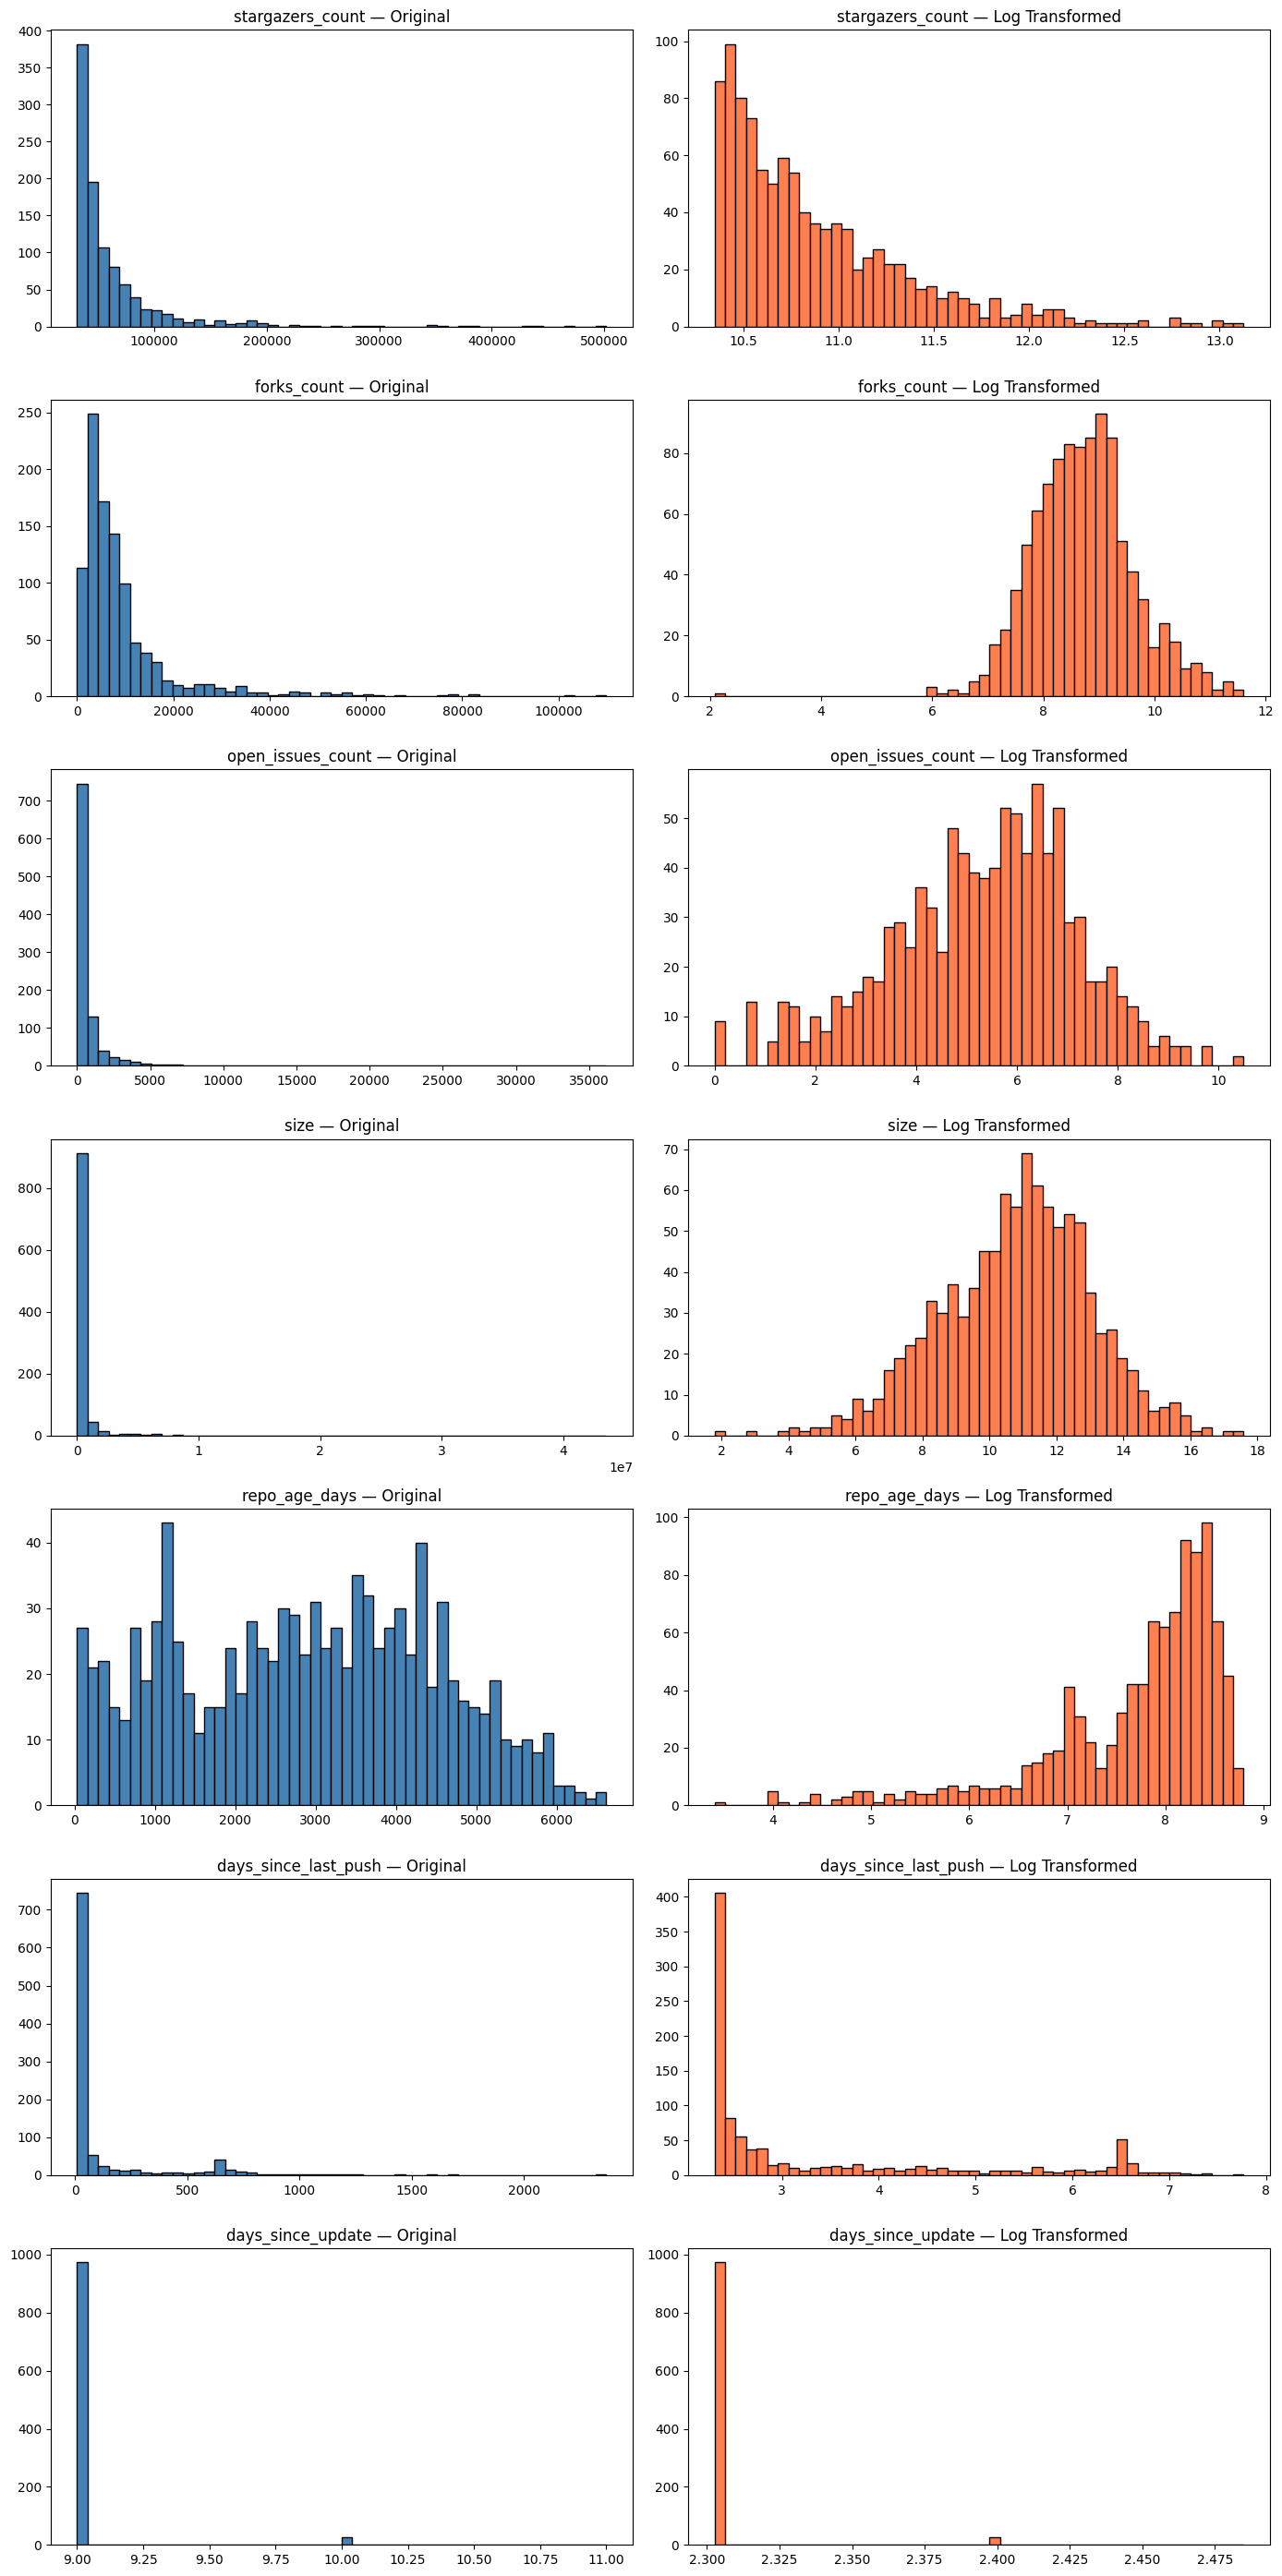

In [36]:
#Log transform for the heavily right-skewed data

skewed_features = ['stargazers_count', 'forks_count', 'open_issues_count', 'size',
                   'repo_age_days', 'days_since_last_push', 'days_since_update']

fig, axes = plt.subplots(len(skewed_features), 2, figsize=(14, 4 * len(skewed_features)))

for i, col in enumerate(skewed_features):
    if col in df.columns:
        axes[i, 0].hist(df[col], bins=50, color='steelblue', edgecolor='k')
        axes[i, 0].set_title(f'{col} — Original')

        log_vals = np.log1p(df[col])
        axes[i, 1].hist(log_vals, bins=50, color='coral', edgecolor='k')
        axes[i, 1].set_title(f'{col} — Log Transformed')

plt.tight_layout()
plt.savefig('skewness_check.png', dpi=150)
plt.show()

In [37]:
#Apply log1p to confirmed skewed features
features_to_log = ['forks_count', 'open_issues_count', 'size',
                   'repo_age_days', 'days_since_last_push', 'days_since_update']

df['stargazers_count_log'] = np.log1p(df['stargazers_count'])

for col in features_to_log:
    if col in df.columns:
        df[f'{col}_log'] = np.log1p(df[col])
        df = df.drop(columns=[col])

=== Correlation with Star Count ===
stargazers_count_log        0.910
forks_count_log             0.560
open_issues_count_log       0.079
language_encoded            0.060
license_encoded             0.058
topic_count                 0.028
size_log                    0.005
repo_age_days_log          -0.001
has_pages                  -0.018
days_since_last_push_log   -0.052
days_since_update_log      -0.081
has_wiki                   -0.095
has_projects               -0.103
Name: stargazers_count, dtype: float64


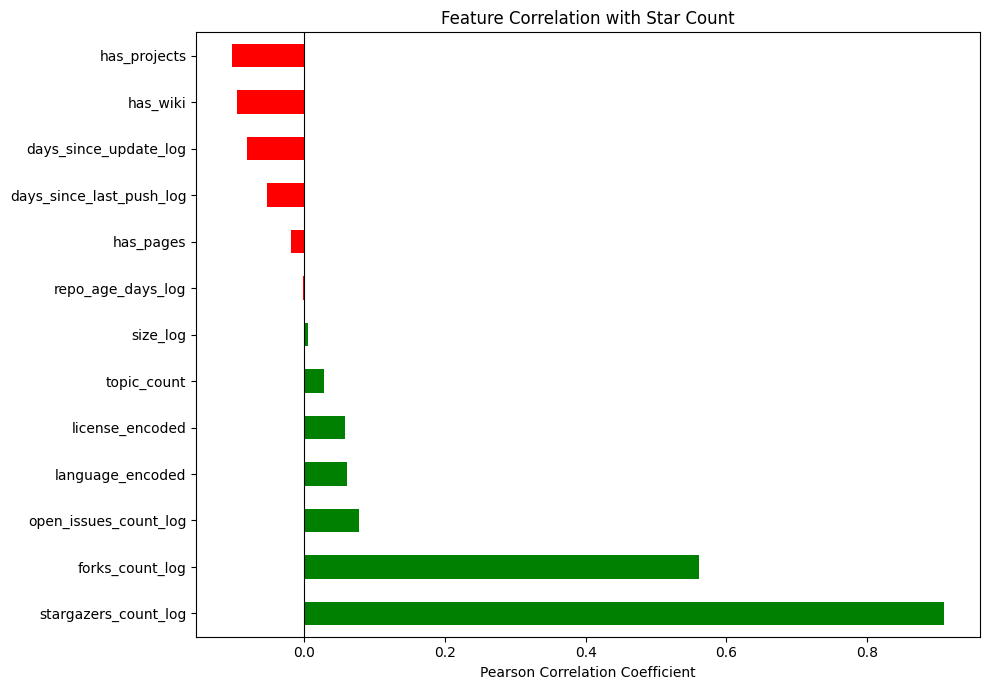

In [38]:
#Computing correlation of all features against stargazers_count
corr_matrix = df.corr(numeric_only=True)

target_corr = corr_matrix['stargazers_count'].drop('stargazers_count').sort_values(ascending=False)

print("=== Correlation with Star Count ===")
print(target_corr.round(3))

plt.figure(figsize=(10, 7))
target_corr.plot(kind='barh', color=['green' if x > 0 else 'red' for x in target_corr])
plt.axvline(0, color='black', linewidth=0.8)
plt.title('Feature Correlation with Star Count')
plt.xlabel('Pearson Correlation Coefficient')
plt.tight_layout()
plt.savefig('correlation_bar.png', dpi=150)
plt.show()

In [39]:
print("days_since_update_log variance:", df['days_since_update_log'].var())
print("days_since_update_log unique values:", df['days_since_update_log'].nunique())

df = df.drop(columns=['days_since_update_log'])
# Drop the leakage column and the near-constant column
df = df.drop(columns=['stargazers_count_log', 'days_since_update_log'], errors='ignore')

days_since_update_log variance: 0.0002863211870686586
days_since_update_log unique values: 3


In [40]:
cols_to_drop = [
    'size_log',           # zero correlation
    'repo_age_days_log',  # zero correlation
    'has_pages',          # near-zero, noise
    'language_encoded',   # arbitrary integer encoding, misleading for linear models
    'license_encoded',    # same problem
]

df = df.drop(columns=[col for col in cols_to_drop if col in df.columns])

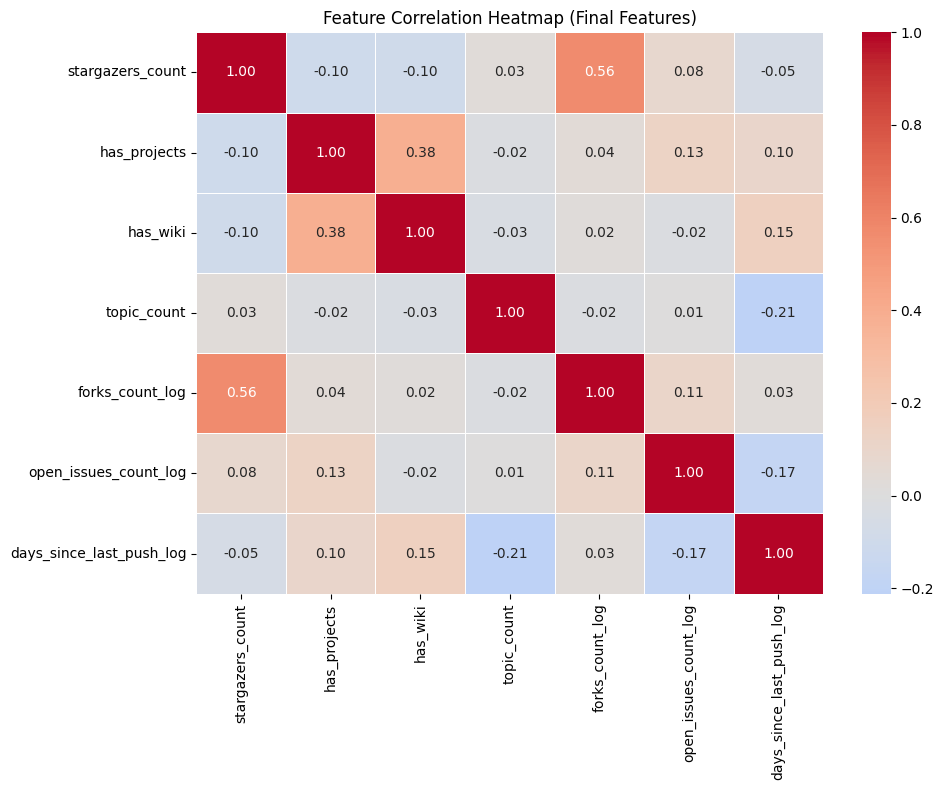

In [41]:
plt.figure(figsize=(10, 8))
sns.heatmap(
    df.corr(numeric_only=True),
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    center=0,
    linewidths=0.5
)
plt.title('Feature Correlation Heatmap (Final Features)')
plt.tight_layout()
plt.savefig('correlation_heatmap_final.png', dpi=150)
plt.show()

In [42]:
df.to_csv('github_features_clean.csv', index=False)